In [1]:
import pandas as pd
import numpy as np

coverage = pd.read_excel('coverage-data.xlsx')
incidence = pd.read_excel('incidence-rate-data.xlsx')
cases = pd.read_excel('reported-cases-data.xlsx')
intro = pd.read_excel('vaccine-introduction-data.xlsx')
schedule = pd.read_excel('vaccine-schedule-data.xlsx')

for name, df in [('Coverage', coverage), ('Incidence', incidence), ('Cases', cases),
                  ('Introduction', intro), ('Schedule', schedule)]:
    print(f"{name}: {df.shape}, duplicates: {df.duplicated().sum()}")

Coverage: (399859, 11), duplicates: 0
Incidence: (84946, 8), duplicates: 0
Cases: (84870, 7), duplicates: 0
Introduction: (138321, 6), duplicates: 0
Schedule: (8053, 12), duplicates: 0


In [2]:
for name, df in [('Coverage', coverage), ('Incidence', incidence), ('Cases', cases),
                  ('Introduction', intro), ('Schedule', schedule)]:
    print(f"--- {name} ---")
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print()

# Coverage mein ek row hai jisme sab kuch missing hai (CODE, YEAR, ANTIGEN sab) — dekhते hain
print("Fully broken row in Coverage:")
print(coverage[coverage['CODE'].isnull()])

--- Coverage ---
CODE                                  1
NAME                               1275
YEAR                                  1
ANTIGEN                               1
ANTIGEN_DESCRIPTION                   1
COVERAGE_CATEGORY                     1
COVERAGE_CATEGORY_DESCRIPTION         1
TARGET_NUMBER                    320829
DOSES                            320532
COVERAGE                         169382
dtype: int64

--- Incidence ---
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
DENOMINATOR                1
INCIDENCE_RATE         23362
dtype: int64

--- Cases ---
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
CASES                  19400
dtype: int64

--- Introduction ---
COUNTRYNAME    1
WHO_REGION     1
YEAR           1
DESCRIPTION    1
INTRO          1
dtype: int64

--- Schedule

In [3]:
coverage = coverage.dropna(subset=['CODE'])
incidence = incidence.dropna(subset=['CODE'])
cases = cases.dropna(subset=['CODE'])
intro = intro.dropna(subset=['ISO_3_CODE'])
schedule = schedule.dropna(subset=['ISO_3_CODE'])

print("Rows after removing footer:")
for name, df in [('Coverage', coverage), ('Incidence', incidence), ('Cases', cases), ('Introduction', intro), ('Schedule', schedule)]:
    print(f"{name}: {df.shape}")

Rows after removing footer:
Coverage: (399858, 11)
Incidence: (84945, 8)
Cases: (84869, 7)
Introduction: (138321, 6)
Schedule: (8053, 12)


In [4]:
print("Remaining NAME-missing rows in Coverage:", coverage['NAME'].isnull().sum())
print(coverage[coverage['NAME'].isnull()]['GROUP'].value_counts())
print(coverage[coverage['NAME'].isnull()]['CODE'].unique()[:20])

Remaining NAME-missing rows in Coverage: 1274
GROUP
WB_LONG     637
WB_SHORT    637
Name: count, dtype: int64
<StringArray>
['WB_LONG_NA', 'WB_SHORT_NA']
Length: 2, dtype: str


In [5]:
print("All GROUP values in Coverage:")
print(coverage['GROUP'].value_counts())

All GROUP values in Coverage:
GROUP
COUNTRIES             381041
UNICEF_REGIONS          4660
WB_LONG                 3767
WHO_REGIONS             3757
WB_SHORT                2564
DEVELOPMENT_STATUS      2230
GAVI_PHASE5             1194
GLOBAL                   645
Name: count, dtype: int64


In [6]:
coverage_countries = coverage[coverage['GROUP'] == 'COUNTRIES'].copy()
coverage_groups = coverage[coverage['GROUP'] != 'COUNTRIES'].copy()

print("Country-level rows:", coverage_countries.shape)
print("Group-level (income/region) rows:", coverage_groups.shape)
print("\nGroup-level breakdown:")
print(coverage_groups['GROUP'].value_counts())

Country-level rows: (381041, 11)
Group-level (income/region) rows: (18817, 11)

Group-level breakdown:
GROUP
UNICEF_REGIONS        4660
WB_LONG               3767
WHO_REGIONS           3757
WB_SHORT              2564
DEVELOPMENT_STATUS    2230
GAVI_PHASE5           1194
GLOBAL                 645
Name: count, dtype: int64


In [7]:
print("Incidence GROUP values:")
print(incidence['GROUP'].value_counts() if 'GROUP' in incidence.columns else "No GROUP column")
print("\nCases GROUP values:")
print(cases['GROUP'].value_counts() if 'GROUP' in cases.columns else "No GROUP column")

Incidence GROUP values:
GROUP
COUNTRIES      82054
WHO_REGIONS     2467
GLOBAL           424
Name: count, dtype: int64

Cases GROUP values:
GROUP
COUNTRIES      82054
WHO_REGIONS     2391
GLOBAL           424
Name: count, dtype: int64


In [8]:
incidence_countries = incidence[incidence['GROUP'] == 'COUNTRIES'].copy()
incidence_groups = incidence[incidence['GROUP'] != 'COUNTRIES'].copy()

cases_countries = cases[cases['GROUP'] == 'COUNTRIES'].copy()
cases_groups = cases[cases['GROUP'] != 'COUNTRIES'].copy()

# Introduction/Schedule mein GROUP column nahi hai — already country-level hain, seedha rakho
print("Final shapes (country-level):")
print("Coverage:", coverage_countries.shape)
print("Incidence:", incidence_countries.shape)
print("Cases:", cases_countries.shape)
print("Introduction:", intro.shape)
print("Schedule:", schedule.shape)

# Sabko CSV mein save karo — SQL load karne ke liye zaroori hai
coverage_countries.to_csv('coverage_countries.csv', index=False)
coverage_groups.to_csv('coverage_groups.csv', index=False)
incidence_countries.to_csv('incidence_countries.csv', index=False)
incidence_groups.to_csv('incidence_groups.csv', index=False)
cases_countries.to_csv('cases_countries.csv', index=False)
cases_groups.to_csv('cases_groups.csv', index=False)
intro.to_csv('vaccine_introduction.csv', index=False)
schedule.to_csv('vaccine_schedule.csv', index=False)
print("\nAll files saved.")

Final shapes (country-level):
Coverage: (381041, 11)
Incidence: (82054, 8)
Cases: (82054, 7)
Introduction: (138321, 6)
Schedule: (8053, 12)

All files saved.


In [9]:
import sqlite3

conn = sqlite3.connect('vaccination.db')

coverage_countries.to_sql('coverage', conn, if_exists='replace', index=False)
incidence_countries.to_sql('incidence', conn, if_exists='replace', index=False)
cases_countries.to_sql('cases', conn, if_exists='replace', index=False)
intro.to_sql('vaccine_introduction', conn, if_exists='replace', index=False)
schedule.to_sql('vaccine_schedule', conn, if_exists='replace', index=False)

# Group-level (income/region) tables bhi rakhte hain — alag purpose ke liye
coverage_groups.to_sql('coverage_groups', conn, if_exists='replace', index=False)
incidence_groups.to_sql('incidence_groups', conn, if_exists='replace', index=False)
cases_groups.to_sql('cases_groups', conn, if_exists='replace', index=False)

conn.commit()

# Verify — sab tables list karo
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print("Tables created:", cursor.fetchall())

# Row count check har table mein
for table in ['coverage', 'incidence', 'cases', 'vaccine_introduction', 'vaccine_schedule']:
    cursor.execute(f"SELECT COUNT(*) FROM {table}")
    print(f"{table}: {cursor.fetchone()[0]} rows")

Tables created: [('coverage',), ('incidence',), ('cases',), ('vaccine_introduction',), ('vaccine_schedule',), ('coverage_groups',), ('incidence_groups',), ('cases_groups',)]
coverage: 381041 rows
incidence: 82054 rows
cases: 82054 rows
vaccine_introduction: 138321 rows
vaccine_schedule: 8053 rows


In [10]:
cov_codes = set(coverage_countries['CODE'].unique())
intro_codes = set(intro['ISO_3_CODE'].unique())
print("Codes in Coverage but not in Introduction:", len(cov_codes - intro_codes))
print("Codes in Introduction but not in Coverage:", len(intro_codes - cov_codes))
print("Common codes:", len(cov_codes & intro_codes))

Codes in Coverage but not in Introduction: 20
Codes in Introduction but not in Coverage: 1
Common codes: 194


In [11]:
print("In Coverage, not in Introduction:", sorted(cov_codes - intro_codes))
print("In Introduction, not in Coverage:", sorted(intro_codes - cov_codes))

In Coverage, not in Introduction: ['ABW', 'AIA', 'ASM', 'BMU', 'CUW', 'CYM', 'GUM', 'HKG', 'MAC', 'MNP', 'MSR', 'NCL', 'PSE', 'PYF', 'SXM', 'TCA', 'TKL', 'VGB', 'WLF', 'XKX']
In Introduction, not in Coverage: ['Created: 2025-02-01 07:09 UTC']


In [12]:
intro = intro.dropna(subset=['COUNTRYNAME'])
schedule = schedule.dropna(subset=['COUNTRYNAME'])  # same issue yahan bhi ho sakta hai, safe rehne ke liye

print("Introduction after fix:", intro.shape)
print("Schedule after fix:", schedule.shape)

# Dobara verify
intro_codes = set(intro['ISO_3_CODE'].unique())
print("Codes in Introduction now:", len(intro_codes))
print("Footer artifact gone?", 'Created: 2025-02-01 07:09 UTC' not in intro_codes)

# Dobara save karo fixed version
intro.to_csv('vaccine_introduction.csv', index=False)
schedule.to_csv('vaccine_schedule.csv', index=False)

Introduction after fix: (138320, 6)
Schedule after fix: (8052, 12)
Codes in Introduction now: 194
Footer artifact gone? True


In [13]:
# Fixed intro/schedule ke saath dobara load
intro.to_sql('vaccine_introduction', conn, if_exists='replace', index=False)
schedule.to_sql('vaccine_schedule', conn, if_exists='replace', index=False)
conn.commit()

cursor.execute("SELECT COUNT(*) FROM vaccine_introduction")
print("vaccine_introduction:", cursor.fetchone()[0], "rows")
cursor.execute("SELECT COUNT(*) FROM vaccine_schedule")
print("vaccine_schedule:", cursor.fetchone()[0], "rows")

vaccine_introduction: 138320 rows
vaccine_schedule: 8052 rows


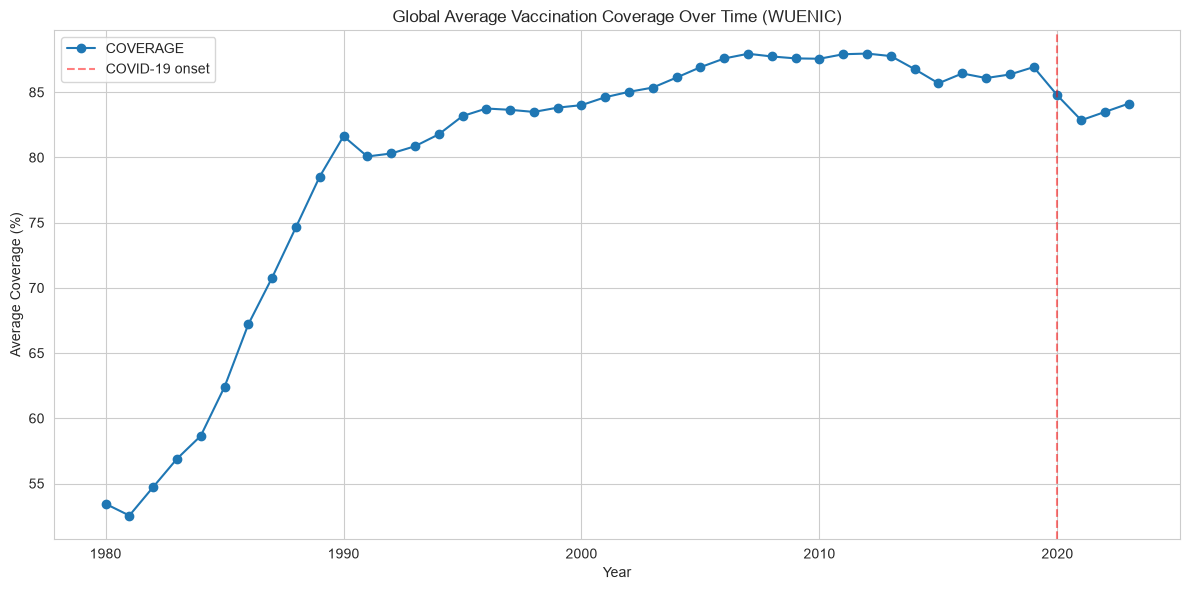

YEAR
2014.0    86.771186
2015.0    85.687349
2016.0    86.441729
2017.0    86.089991
2018.0    86.362736
2019.0    86.930667
2020.0    84.753195
2021.0    82.856899
2022.0    83.495809
2023.0    84.134719
Name: COVERAGE, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

wuenic = coverage_countries[coverage_countries['COVERAGE_CATEGORY']=='WUENIC'].dropna(subset=['COVERAGE'])

global_trend = wuenic.groupby('YEAR')['COVERAGE'].mean()

plt.figure(figsize=(12,6))
global_trend.plot(marker='o')
plt.title('Global Average Vaccination Coverage Over Time (WUENIC)')
plt.ylabel('Average Coverage (%)')
plt.xlabel('Year')
plt.axvline(2020, color='red', linestyle='--', alpha=0.5, label='COVID-19 onset')
plt.legend()
plt.tight_layout()
plt.show()

print(global_trend.tail(10))

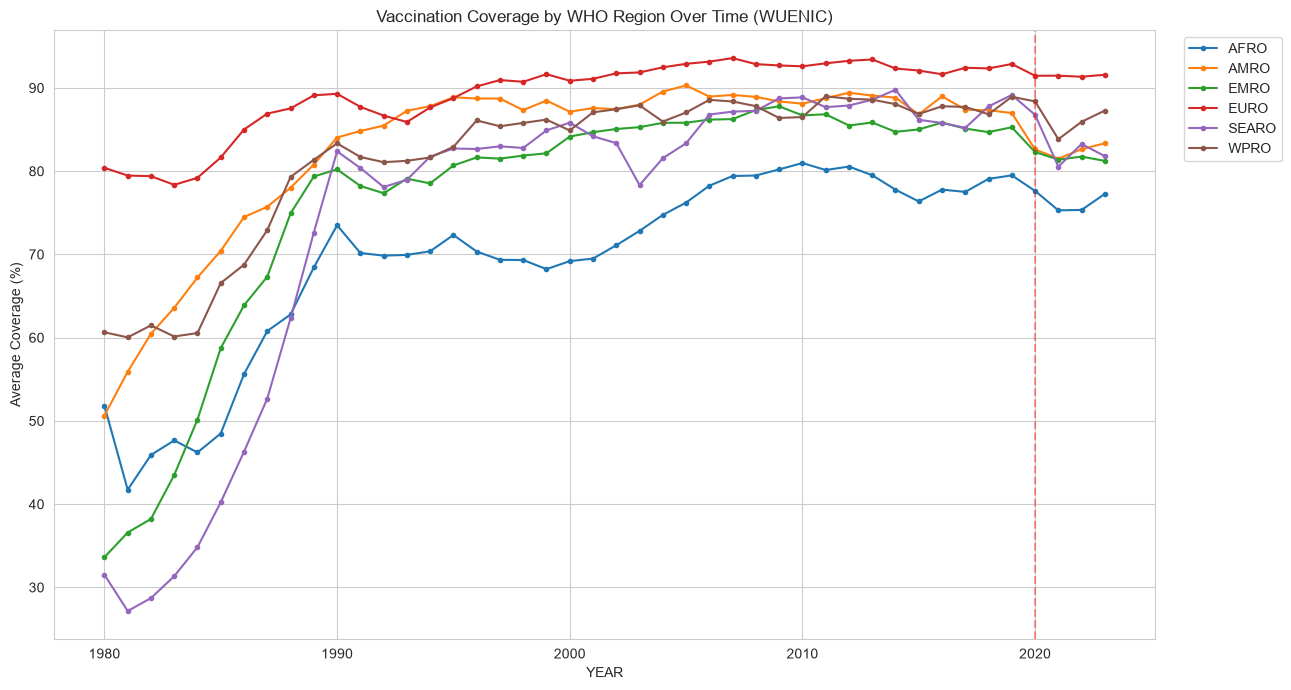

YEAR           2019.0     2021.0     2023.0
WHO_REGION                                 
AFRO        79.495479  75.292683  77.271215
AMRO        86.976359  81.497748  83.345212
EMRO        85.272358  81.384906  81.231618
EURO        92.873921  91.468908  91.581395
SEARO       89.154472  80.534884  81.796992
WPRO        88.939297  83.837920  87.281437


In [15]:
# WHO Region-wise trend comparison
wuenic_with_region = coverage_countries.merge(
    intro[['ISO_3_CODE', 'WHO_REGION']].drop_duplicates(),
    left_on='CODE', right_on='ISO_3_CODE', how='left'
)
wuenic_region = wuenic_with_region[wuenic_with_region['COVERAGE_CATEGORY']=='WUENIC'].dropna(subset=['COVERAGE'])

region_trend = wuenic_region.groupby(['YEAR', 'WHO_REGION'])['COVERAGE'].mean().unstack()

plt.figure(figsize=(13,7))
region_trend.plot(ax=plt.gca(), marker='.')
plt.title('Vaccination Coverage by WHO Region Over Time (WUENIC)')
plt.ylabel('Average Coverage (%)')
plt.axvline(2020, color='red', linestyle='--', alpha=0.4)
plt.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

print(region_trend.loc[[2019, 2021, 2023]].T)

In [16]:
measles_cov = coverage_countries[
    (coverage_countries['ANTIGEN'].str.contains('MCV', case=False, na=False)) &
    (coverage_countries['COVERAGE_CATEGORY']=='WUENIC')
][['CODE','NAME','YEAR','ANTIGEN','COVERAGE']]

measles_inc = incidence_countries[
    incidence_countries['DISEASE'].str.contains('Measles', case=False, na=False)
][['CODE','YEAR','INCIDENCE_RATE']]

print("Measles antigen codes found:", measles_cov['ANTIGEN'].unique())
print("Measles coverage rows:", measles_cov.shape)
print("Measles incidence rows:", measles_inc.shape)

merged = measles_cov.merge(measles_inc, on=['CODE','YEAR'], how='inner')
print("\nMerged rows:", merged.shape)

correlation = merged[['COVERAGE','INCIDENCE_RATE']].corr()
print("\nCorrelation (coverage vs incidence rate):")
print(correlation)

Measles antigen codes found: <StringArray>
['MCV1', 'MCV2']
Length: 2, dtype: str
Measles coverage rows: (12828, 5)
Measles incidence rows: (8888, 3)

Merged rows: (12615, 6)

Correlation (coverage vs incidence rate):
                COVERAGE  INCIDENCE_RATE
COVERAGE        1.000000       -0.189286
INCIDENCE_RATE -0.189286        1.000000


MCV1-only merged rows: (8051, 5)
Correlation (MCV1 coverage vs incidence rate):
                COVERAGE  INCIDENCE_RATE
COVERAGE        1.000000       -0.214419
INCIDENCE_RATE -0.214419        1.000000


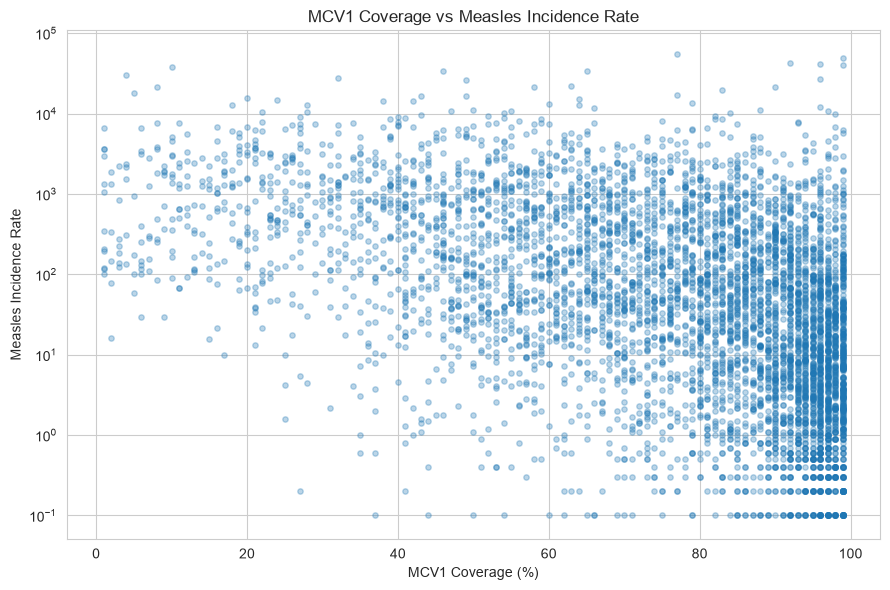

In [17]:
measles_cov_mcv1 = coverage_countries[
    (coverage_countries['ANTIGEN']=='MCV1') &
    (coverage_countries['COVERAGE_CATEGORY']=='WUENIC')
][['CODE','NAME','YEAR','COVERAGE']]

merged_mcv1 = measles_cov_mcv1.merge(measles_inc, on=['CODE','YEAR'], how='inner')
print("MCV1-only merged rows:", merged_mcv1.shape)
print("Correlation (MCV1 coverage vs incidence rate):")
print(merged_mcv1[['COVERAGE','INCIDENCE_RATE']].corr())

# Scatter plot bhi dekhte hain — sirf number se pura pattern nahi dikhta
plt.figure(figsize=(9,6))
plt.scatter(merged_mcv1['COVERAGE'], merged_mcv1['INCIDENCE_RATE'], alpha=0.3, s=15)
plt.xlabel('MCV1 Coverage (%)')
plt.ylabel('Measles Incidence Rate')
plt.title('MCV1 Coverage vs Measles Incidence Rate')
plt.yscale('log')  # incidence rate skewed hota hai, log scale se pattern behtar dikhega
plt.tight_layout()
plt.show()

              median         mean  count
coverage_bin                            
<50%           400.6  1476.241657    881
50-70%          98.0   718.769658   1081
70-80%          40.9   468.188670    812
80-90%           8.6   253.087670   1468
90-95%           2.1   135.493980   1279
95-100%          1.0   179.837692   1759


C:\Users\ASUS\AppData\Local\Temp\ipykernel_15216\3302544373.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_summary.index, y=bin_summary['median'], palette='rocket')


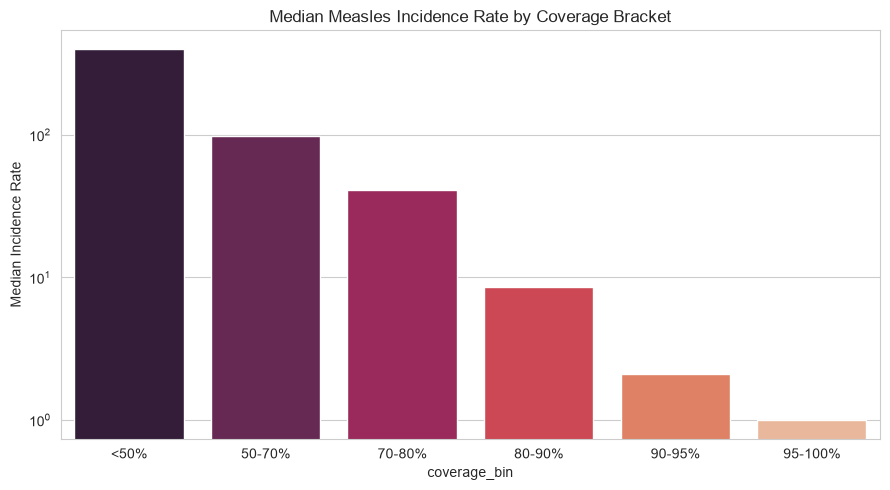

In [18]:
merged_mcv1['coverage_bin'] = pd.cut(merged_mcv1['COVERAGE'], bins=[0,50,70,80,90,95,100],
                                       labels=['<50%','50-70%','70-80%','80-90%','90-95%','95-100%'])

bin_summary = merged_mcv1.groupby('coverage_bin', observed=True)['INCIDENCE_RATE'].agg(['median','mean','count'])
print(bin_summary)

plt.figure(figsize=(9,5))
sns.barplot(x=bin_summary.index, y=bin_summary['median'], palette='rocket')
plt.title('Median Measles Incidence Rate by Coverage Bracket')
plt.ylabel('Median Incidence Rate')
plt.yscale('log')
plt.tight_layout()
plt.show()

## EDA Findings So Far

1. **COVID-19 impact**: Global coverage dropped from 86.9% (2019) to 82.9% (2021), and still hasn't recovered to pre-pandemic levels by 2023 (84.1%).
2. **Regional disparity**: SEARO hit hardest by COVID (-8.6 points), EMRO shows no recovery 2021-2023. EURO consistently highest (~92%) and most stable; AFRO consistently lowest (~79%).
3. **Measles campaign effectiveness**: Countries with 95-100% MCV1 coverage show median incidence of 1.0, vs. 400.6 in countries under 50% coverage — a 400x difference. Raw linear correlation (-0.21) understates this due to a non-linear "ceiling effect" relationship.

**Data limitation noted**: No demographic breakdowns (gender, education, urban/rural) exist in the provided tables — several brief questions on these dimensions cannot be answered with this dataset.